# N-Mass-Spring-Damper System
## System Configuration
- N masses connected in series by springs and dampers
- Last mass connected to fixed wall via spring and damper
- Input force on first mass: F(t) = sin(ωt)
- All masses rendered in black for clarity
- System simulated over t_end seconds

In [1]:
from mass_spring_system import MassSpringDamperSystem

# ============================================================
# SYSTEM CONFIGURATION
# ============================================================
# Create system with custom parameters
system = MassSpringDamperSystem(
    n=10,                    # number of masses
    m=1.0,                   # mass (kg)
    k=10.0,                  # spring constant (N/m)
    c=0.5,                   # damping coefficient (N·s/m)
    mu_friction=0.5,         # friction coefficient
    omega=1.75,              # input frequency (rad/s)
    amplitude=10.0,          # input force amplitude (N)
    t_end=10.0,              # simulation time (seconds)
    num_points=10000         # number of time points
)

Mass-Spring-Damper System Configuration:
  Number of masses: 10
  Masses: 1.0 kg (uniform)
  Spring constants: 10.0 N/m (uniform)
  Damping coefficients: 0.5 N·s/m (uniform)
  Friction coefficient (μ): 0.5
  Input force: F(t) = 10.0·sin(1.75·t) N
  Simulation time: 10.0 seconds



## State Space Formulation
State vector: **x** = [x₁, x₂, ..., xₙ, ẋ₁, ẋ₂, ..., ẋₙ]ᵀ

**Equations of Motion (General n-mass system):**
- **Mass 1**: m₁·ẍ₁ = F(t) - k₁(x₁-x₂) - c₁(ẋ₁-ẋ₂)
- **Mass i** (1 < i < n): mᵢ·ẍᵢ = kᵢ₋₁(xᵢ₋₁-xᵢ) + cᵢ₋₁(ẋᵢ₋₁-ẋᵢ) - kᵢ(xᵢ-xᵢ₊₁) - cᵢ(ẋᵢ-ẋᵢ₊₁)
- **Mass n**: mₙ·ẍₙ = kₙ₋₁(xₙ₋₁-xₙ) + cₙ₋₁(ẋₙ₋₁-ẋₙ) - kₙ·xₙ - cₙ·ẋₙ

The last mass is connected to a fixed wall via spring kₙ and damper cₙ.

Input force: F(t) = A·sin(ωt)

In [2]:
# ============================================================
# SOLVE THE SYSTEM
# ============================================================
positions, velocities = system.solve()

Simulation completed successfully!
  Final positions (m): [-3.62696945e-01  2.84424533e-01  6.15640399e-02 -1.98199120e-04
 -8.14379004e-05 -5.57820991e-06 -2.56448015e-07 -8.52590944e-09
 -2.17415366e-10 -4.42723492e-12]
  Final velocities (m/s): [-2.01829761e+00 -1.27051263e+00  2.07839315e-03  1.26791575e-03
  4.03883556e-07 -1.43503375e-06 -1.04645922e-07 -4.97779587e-09
 -1.69582842e-10 -4.40900252e-12]



In [3]:
# ============================================================
# PLOT TRAJECTORIES (Positions and Velocities)
# ============================================================
#system.plot_trajectories()

In [4]:
# ============================================================
# PLOT PHASE PORTRAITS (Position vs Velocity for each mass)
# ============================================================
#system.plot_phase_portraits()

# TODO Also: Find spring energy and damping losses 

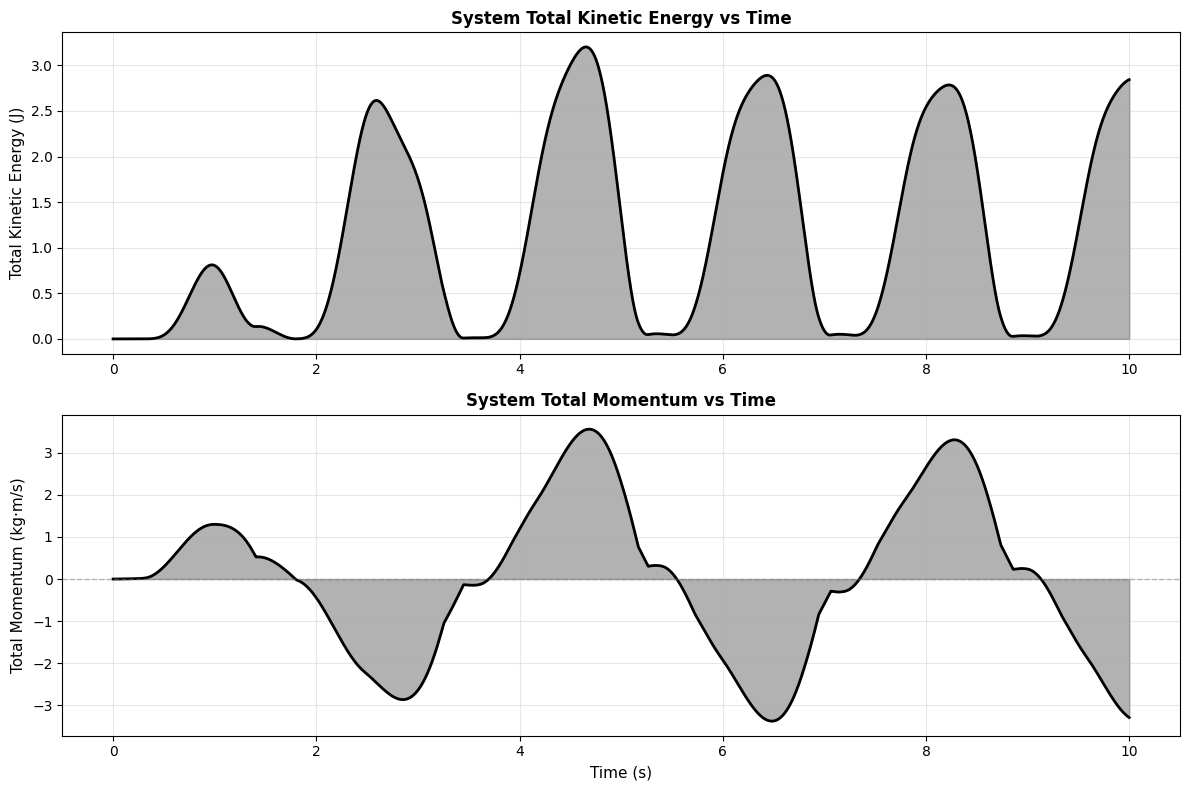

Energy and Momentum Statistics:
  Maximum kinetic energy: 3.2025 J
  Final kinetic energy: 2.8439 J
  Maximum total momentum: 3.5572 kg·m/s
  Final total momentum: -3.2855 kg·m/s



In [5]:
# ============================================================
# PLOT ENERGY AND MOMENTUM
# ============================================================
system.plot_energy_momentum()

In [9]:
# ============================================================
# GENERATE ANIMATION
# ============================================================
if True:
    from IPython.display import Video, display

    video_path = system.animate(fps=20)
    display(Video(video_path, embed=True))

Generating animation (200 frames at 20 fps)...
  20/200 frames (10%)
  40/200 frames (20%)
  60/200 frames (30%)
  80/200 frames (40%)
  100/200 frames (50%)
  120/200 frames (60%)
  140/200 frames (70%)
  160/200 frames (80%)
  180/200 frames (90%)
  200/200 frames (100%)
✓ Frames generated in 5.4s
Encoding video...


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1200, 300) to (1200, 304) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


✓ Video saved: C:\Users\OSVALD~1\AppData\Local\Temp\tmply9lqkj0\animation.mp4
  Size: 0.07 MB
  Duration: 10.0 seconds



In [7]:
# ============================================================
# OPTIONAL: Custom System Configuration Examples
# ============================================================
# You can create systems with different parameters:

# Example 1: High friction system
# system2 = MassSpringDamperSystem(n=5, k=20.0, mu_friction=1.0, amplitude=100.0)
# system2.solve()
# system2.plot_trajectories()

# Example 2: System with variable mass
# m_varied = [1.0, 1.5, 1.0, 1.5, 1.0]  # alternating masses
# system3 = MassSpringDamperSystem(n=5, m=m_varied, k=15.0)
# system3.solve()
# system3.animate(fps=30)

# Example 3: Low damping (more oscillatory)
# system4 = MassSpringDamperSystem(n=8, c=0.1, amplitude=5.0)
# system4.solve()
# system4.plot_energy_momentum()

print("Module imported successfully. Edit the system configuration in the first cell and run all cells in order.")

Module imported successfully. Edit the system configuration in the first cell and run all cells in order.


# Frequency Response

Running frequency sweep analysis...

Mass-Spring-Damper System Configuration:
  Number of masses: 10
  Masses: 1.0 kg (uniform)
  Spring constants: 10.0 N/m (uniform)
  Damping coefficients: 0.5 N·s/m (uniform)
  Friction coefficient (μ): 0.5
  Input force: F(t) = 0.10000000000000002·sin(0.1·t) N
  Simulation time: 10.0 seconds

Simulation completed successfully!
  Final positions (m): [8.76510779e-04 5.73566933e-05 2.88425660e-06 1.18277353e-07
 4.12000434e-09 1.25751000e-10 3.44643009e-12 8.64749368e-14
 2.01718507e-15 4.42642794e-17]
  Final velocities (m/s): [1.54705420e-04 1.57114360e-05 1.06748308e-06 5.50016378e-08
 2.29527066e-09 8.10252157e-11 2.49929098e-12 6.90861865e-14
 1.74573334e-15 4.09445127e-17]

  Frequency  1/20: ω =   0.10 rad/s | Max KE =  0.0000 J | Max p =  0.0002 kg·m/s
Mass-Spring-Damper System Configuration:
  Number of masses: 10
  Masses: 1.0 kg (uniform)
  Spring constants: 10.0 N/m (uniform)
  Damping coefficients: 0.5 N·s/m (uniform)
  Friction coefficie

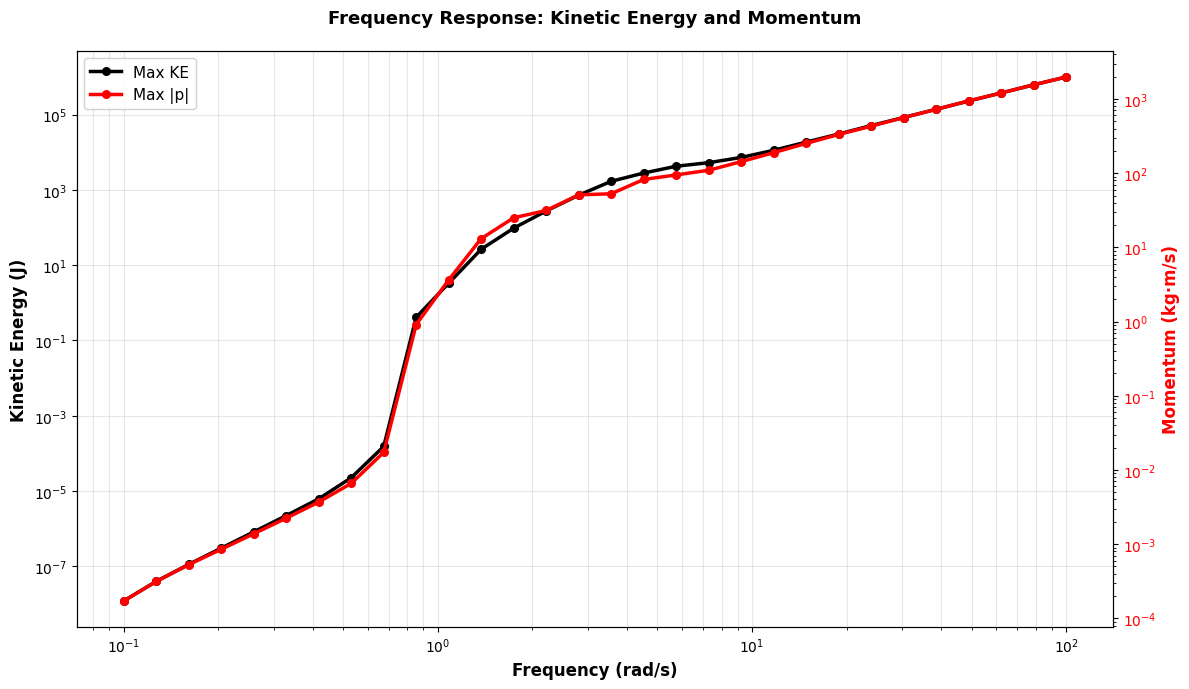

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Define frequency range (rad/s): 0.1 to 100 rad/s logarithmically spaced
frequencies = np.logspace(-1, 2, num=30)

# Storage for results
max_kinetic_energies = []
max_momenta = []
avg_kinetic_energies = []
avg_momenta = []

print("Running frequency sweep analysis...\n")

for i, freq in enumerate(frequencies):
    # Create and solve system for each frequency
    system = MassSpringDamperSystem(
        n=10,                    # number of masses
        m=1.0,                   # mass (kg)
        k=10.0,                  # spring constant (N/m)
        c=0.5,                   # damping coefficient (N·s/m)
        mu_friction=0.5,         # friction coefficient
        omega=freq,              # input frequency (rad/s)
        amplitude=10.0*freq**2,          # input force amplitude varies with frequency (N)
        t_end=10.0,              # simulation time (seconds)
        num_points=1000          # reduced for faster sweep
    )
    
    # Solve system (suppress output)
    positions, velocities = system.solve()
    
    # Calculate kinetic energy vs time
    KE_individual = 0.5 * system.m[np.newaxis, :] * velocities**2
    KE_total = np.sum(KE_individual, axis=1)
    
    # Calculate momentum vs time
    momentum_individual = system.m[np.newaxis, :] * velocities
    momentum_total = np.sum(momentum_individual, axis=1)
    
    # Skip first 20% of data to avoid transient effects
    skip = int(0.2 * len(KE_total))
    
    # Store max and average values (ignoring transients)
    max_kinetic_energies.append(np.max(KE_total[skip:]))
    max_momenta.append(np.max(np.abs(momentum_total[skip:])))
    avg_kinetic_energies.append(np.mean(KE_total[skip:]))
    avg_momenta.append(np.mean(np.abs(momentum_total[skip:])))
    
    print(f"  Frequency {i+1:2d}/20: ω = {freq:6.2f} rad/s | "
          f"Max KE = {max_kinetic_energies[-1]:7.4f} J | "
          f"Max p = {max_momenta[-1]:7.4f} kg·m/s")

print("\nFrequency sweep complete!\n")

# Create dual-axis plot: Kinetic Energy (left, black) and Momentum (right, red)
fig, ax1 = plt.subplots(figsize=(12, 7))

# LEFT AXIS: Kinetic Energy (Black)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.loglog(frequencies, max_kinetic_energies, 'ko-', linewidth=2.5, markersize=4, label='Max KE', mew=2.5)
#ax1.loglog(frequencies, avg_kinetic_energies, 'ko-', linewidth=2.5, markersize=7, label='Avg KE')
ax1.set_xlabel('Frequency (rad/s)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Kinetic Energy (J)', fontsize=12, fontweight='bold', color='k')
ax1.tick_params(axis='y', labelcolor='k')
ax1.grid(True, alpha=0.3, which='both')

# RIGHT AXIS: Momentum (Red)
ax2 = ax1.twinx()
ax2.set_yscale('log')
ax2.loglog(frequencies, max_momenta, 'ro-', linewidth=2.5, markersize=4, label='Max |p|', mew=2.5)
#ax2.loglog(frequencies, avg_momenta, 'ro-', linewidth=2.5, markersize=7, label='Avg |p|')
ax2.set_ylabel('Momentum (kg·m/s)', fontsize=12, fontweight='bold', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Title and combined legend
plt.title('Frequency Response: Kinetic Energy and Momentum', fontsize=13, fontweight='bold', pad=20)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.show()

# Print summary statistics
# print("=" * 70)
# print("FREQUENCY RESPONSE SUMMARY")
# print("=" * 70)
# print(f"Frequency range: {frequencies[0]:.4f} to {frequencies[-1]:.4f} rad/s")
# print(f"\nKinetic Energy:")
# print(f"  Max KE at lowest freq:  {max_kinetic_energies[0]:.4f} J")
# print(f"  Max KE at highest freq: {max_kinetic_energies[-1]:.4f} J")
# print(f"  KE increase ratio: {max_kinetic_energies[-1] / max_kinetic_energies[0]:.2f}x")
# print(f"\nMomentum:")
# print(f"  Max |p| at lowest freq:  {max_momenta[0]:.4f} kg·m/s")
# print(f"  Max |p| at highest freq: {max_momenta[-1]:.4f} kg·m/s")
# print(f"  Momentum increase ratio: {max_momenta[-1] / max_momenta[0]:.2f}x")
# print("=" * 70)